In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import regionmask
import xarray as xr
import cartopy
import cartopy.crs as ccrs
import cmocean

from unseen import fileio

import utils

In [2]:
#import importlib

In [3]:
#importlib.reload(utils)

## Plot grid

In [4]:
infile = '/g/data/xv83/unseen-projects/outputs/bias/data/rx1day_AGCD-CSIRO_1901-2024_annual-jul-to-jun_AUS300i.nc'
ds = fileio.open_dataset(infile)
overlap_threshold = 0.67
shape_gpd = gpd.read_file('/g/data/ia39/aus-ref-clim-data-nci/shapefiles/data/australia/australia.shp')
shape_rgm = regionmask.from_geopandas(
    shape_gpd,
    names="AUS_NAME21",
    abbrevs="AUS_CODE21",
    name="australia"
)
frac = shape_rgm.mask_3D_frac_approx(ds)
mask = frac.sel(region=0) >= overlap_threshold

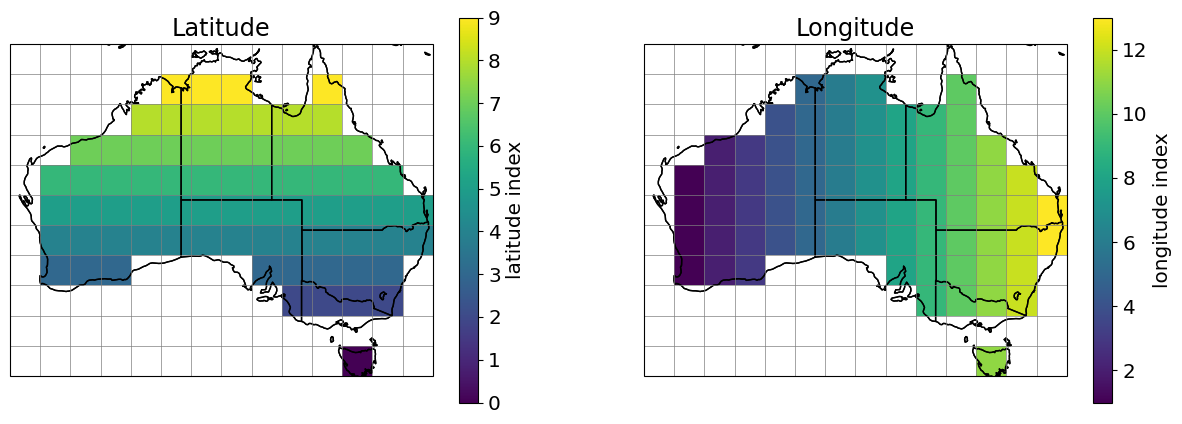

In [5]:
lon_array = xr.DataArray(
#    data=np.tile(mask.lon, (11, 1)),
    data=np.tile(np.arange(0,14), (11, 1)),
    coords={'lat': mask.lat, 'lon': mask.lon},
)

lat_array = xr.DataArray(
#    data=np.squeeze(np.dstack([mask.lat]*14)),
    data=np.squeeze(np.dstack([np.arange(0,11)]*14)),
    coords={'lat': mask.lat, 'lon': mask.lon},
) 

min_lat = mask.lat.values.min() - 1.5
max_lat = mask.lat.values.max() + 1.5
min_lon = mask.lon.values.min() - 1.5
max_lon = mask.lon.values.max() + 1.5

fig = plt.figure(figsize=[15, 5])

ax1 = fig.add_subplot(121, projection=ccrs.PlateCarree())
im1 = lat_array.where(mask).plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'latitude index'},
)
ax1.set_title('Latitude')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)

ax2 = fig.add_subplot(122, projection=ccrs.PlateCarree())
im2 = lon_array.where(mask).plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'longitude index'},
)
ax2.set_title('Longitude')
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)

for lon in mask.lon.values:
    ax1.plot([lon - 1.5, lon - 1.5], [min_lat, max_lat], transform=ccrs.PlateCarree(), color='0.5', lw=0.5)
    ax2.plot([lon - 1.5, lon - 1.5], [min_lat, max_lat], transform=ccrs.PlateCarree(), color='0.5', lw=0.5)
for lat in mask.lat.values:
    ax1.plot([min_lon, max_lon], [lat - 1.5, lat - 1.5], transform=ccrs.PlateCarree(), color='0.5', lw=0.5)
    ax2.plot([min_lon, max_lon], [lat - 1.5, lat - 1.5], transform=ccrs.PlateCarree(), color='0.5', lw=0.5)

plt.show()

## Plot rx1day data

In [4]:
return_period = 1000
infile = 'rx1day_spatial.nc'
ds = xr.open_dataset(infile)

In [5]:
ds

<xarray.Dataset> Size: 19kB
Dimensions:  (lev: 2, lat: 11, lon: 14)
Coordinates:
  * lev      (lev) int64 16B 100 1000
  * lat      (lat) float64 88B -42.0 -39.0 -36.0 -33.0 ... -18.0 -15.0 -12.0
  * lon      (lon) float64 112B 113.5 116.5 119.5 122.5 ... 146.5 149.5 152.5
Data variables:
    G        (lev, lat, lon) float64 2kB ...
    M        (lev, lat, lon) float64 2kB ...
    B        (lev, lat, lon) float64 2kB ...
    T        (lev, lat, lon) float64 2kB ...
    O        (lev, lat, lon) float64 2kB ...
    MMM      (lev, lat, lon) float64 2kB ...
    obs      (lev, lat, lon) float64 2kB ...
    nmodels  (lat, lon) float64 1kB ...
Attributes:
    metric:   rx1day

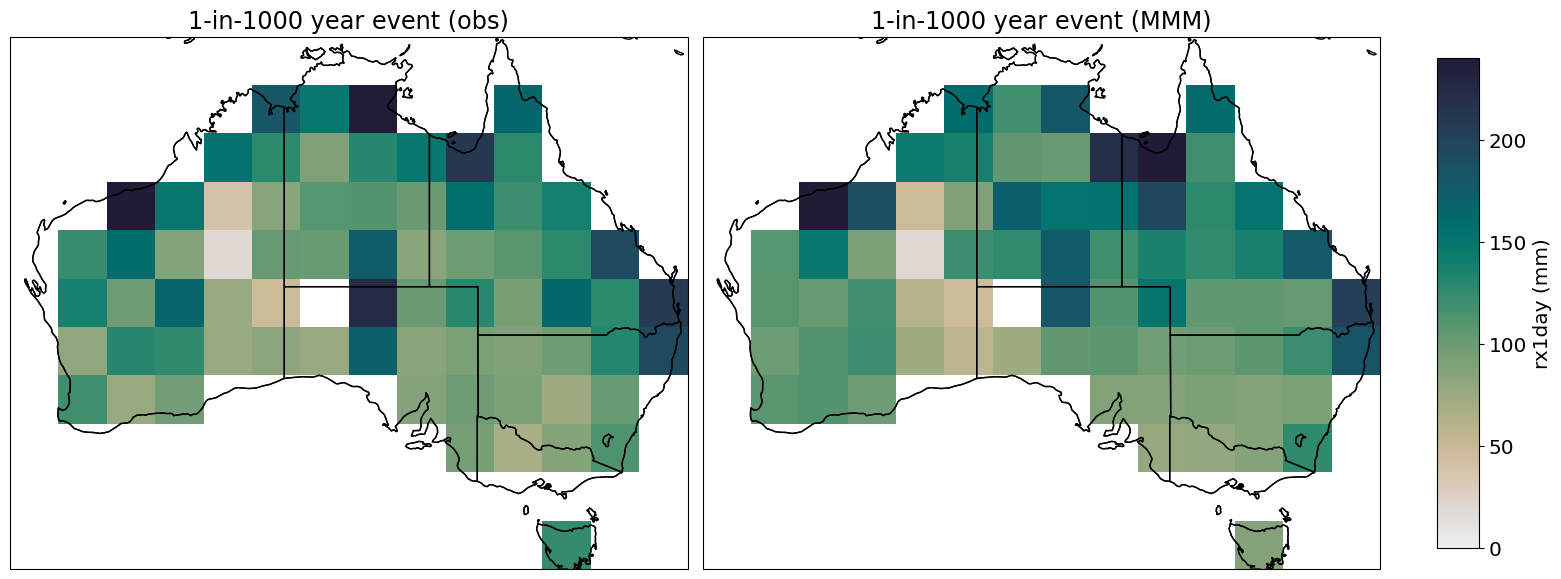

In [17]:
fig = plt.figure(figsize=[14, 7])
cbar_levels = np.arange(0, 241, 30)
cmap = cmocean.cm.rain

ax1 = fig.add_subplot(121, projection=ccrs.PlateCarree())
im1 = ds.sel({'lev': return_period})['obs'].plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
#    levels=cbar_levels,
    vmin=0,
    vmax=240,
    cmap=cmap,
)
ax1.set_title(f'1-in-{return_period} year event (obs)')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)

ax2 = fig.add_subplot(122, projection=ccrs.PlateCarree())
im2 = ds.sel({'lev': return_period})['MMM'].plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
#    levels=cbar_levels,
    vmin=0,
    vmax=240,
    cmap=cmap,
)
ax2.set_title(f'1-in-{return_period} year event (MMM)')
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)

cbar_ax = fig.add_axes([1.03, 0.15, 0.03, 0.7]) # left, bottom, width, height
fig.colorbar(im1, cax=cbar_ax, label='rx1day (mm)')

plt.tight_layout()
plt.show()

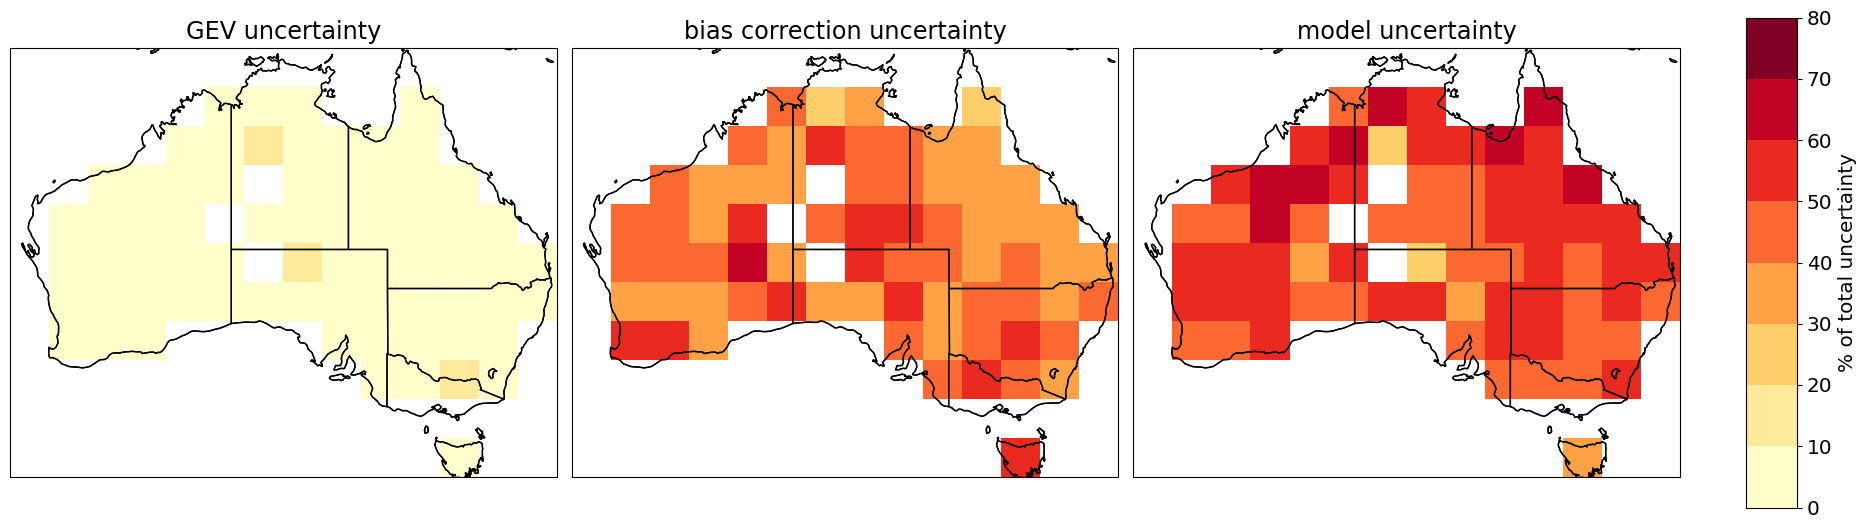

In [47]:
fig = plt.figure(figsize=[17, 7])
cbar_levels = np.arange(0, 81, 10)
cmap = 'YlOrRd'

ax1 = fig.add_subplot(131, projection=ccrs.PlateCarree())
im1 = ds.sel({'lev': return_period})['G'].plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    levels=cbar_levels,
    cmap=cmap,
)
ax1.set_title('GEV uncertainty')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)

ax2 = fig.add_subplot(132, projection=ccrs.PlateCarree())
im2 = ds.sel({'lev': return_period})['B'].plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    levels=cbar_levels,
    cmap=cmap,
)
ax2.set_title('bias correction uncertainty')
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)

ax3 = fig.add_subplot(133, projection=ccrs.PlateCarree())
im3 = ds.sel({'lev': return_period})['M'].plot(
    ax=ax3,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    levels=cbar_levels,
    cmap=cmap,
)
ax3.set_title('model uncertainty')
ax3.coastlines()
ax3.add_feature(cartopy.feature.STATES)

cbar_ax = fig.add_axes([1.03, 0.15, 0.03, 0.7]) # left, bottom, width, height
fig.colorbar(im1, cax=cbar_ax, label='% of total uncertainty')

plt.tight_layout()
plt.show()

In [39]:
ratio = ds.sel({'lev': return_period})['T'] / ds.sel({'lev': return_period})['O']

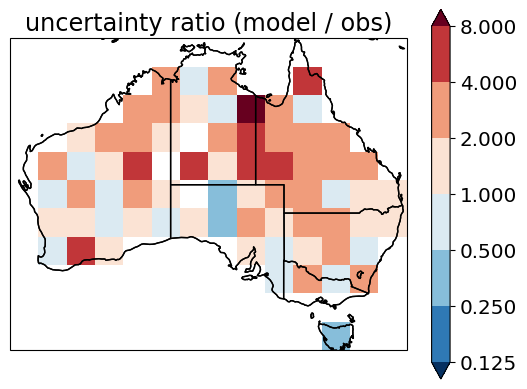

In [40]:
fig = plt.figure()#figsize=[5, 5])

ax1 = fig.add_subplot(111, projection=ccrs.PlateCarree())
im1 = ratio.plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    levels=[1/8, 1/4, 1/2, 1, 2, 4, 8],
    extend='both',
    cmap='RdBu_r'
)
ax1.set_title('uncertainty ratio (model / obs)')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)

plt.show()

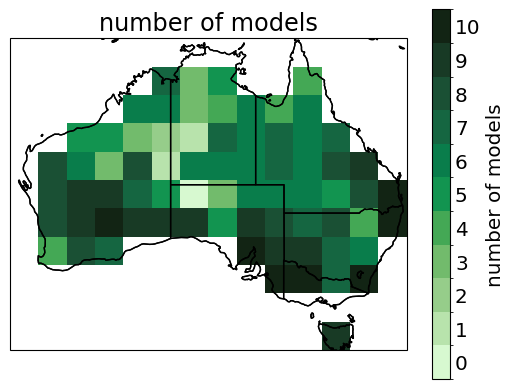

In [12]:
fig = plt.figure()#figsize=[5, 5])

ax1 = fig.add_subplot(111, projection=ccrs.PlateCarree())
im1 = ds['nmodels'].plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
#    cbar_kwargs={'label': ' '},
    levels=np.arange(-0.5, 10.6, 1.0),
#    extend='min',
    cmap=cmocean.cm.algae
)
ax1.set_title('number of models')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)

cbar = fig.colorbar(im1, ticks=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], label='number of models')
cbar.ax.tick_params(size=0)

plt.show()

## Plot txx data

In [18]:
return_period = 1000
infile = 'txx_spatial.nc'
ds = xr.open_dataset(infile)

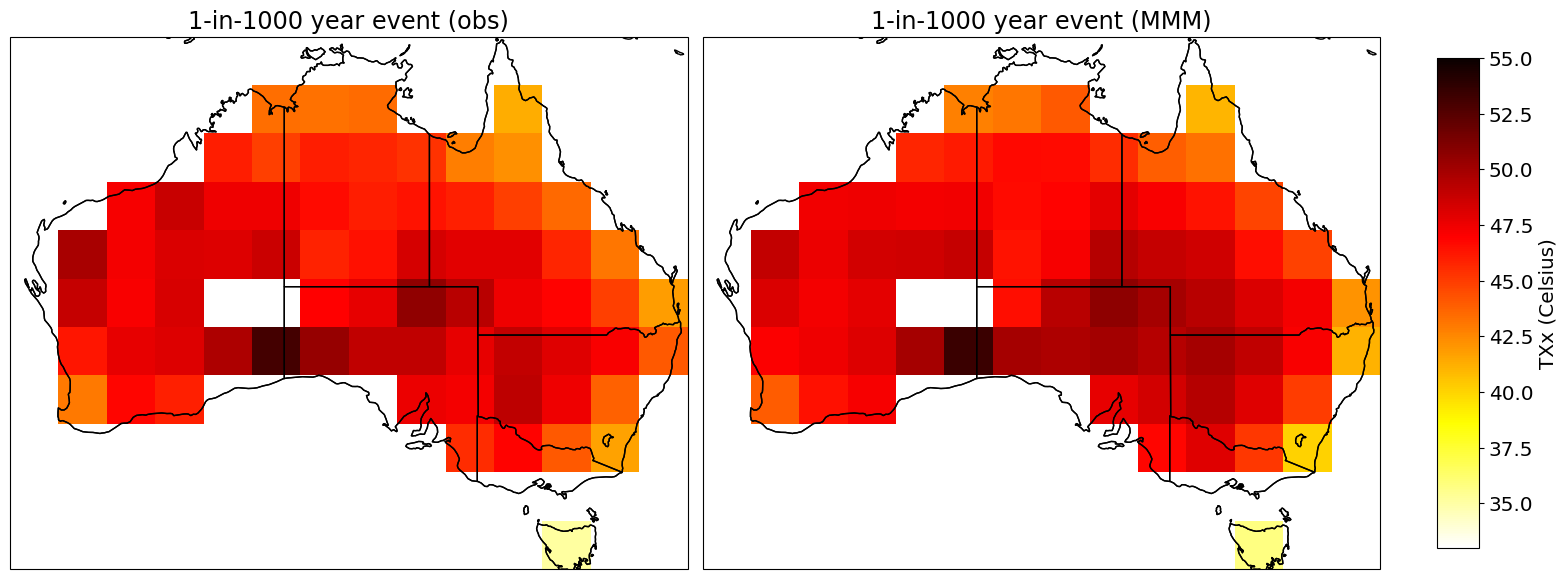

In [21]:
fig = plt.figure(figsize=[14, 7])
cmap = 'hot_r'

ax1 = fig.add_subplot(121, projection=ccrs.PlateCarree())
im1 = ds.sel({'lev': return_period})['obs'].plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
#    levels=cbar_levels,
    vmin=33,
    vmax=55,
    cmap=cmap,
)
ax1.set_title(f'1-in-{return_period} year event (obs)')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)

ax2 = fig.add_subplot(122, projection=ccrs.PlateCarree())
im2 = ds.sel({'lev': return_period})['MMM'].plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
#    levels=cbar_levels,
    vmin=33,
    vmax=55,
    cmap=cmap,
)
ax2.set_title(f'1-in-{return_period} year event (MMM)')
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)

cbar_ax = fig.add_axes([1.03, 0.15, 0.03, 0.7]) # left, bottom, width, height
fig.colorbar(im1, cax=cbar_ax, label='TXx (Celsius)')

plt.tight_layout()
plt.show()

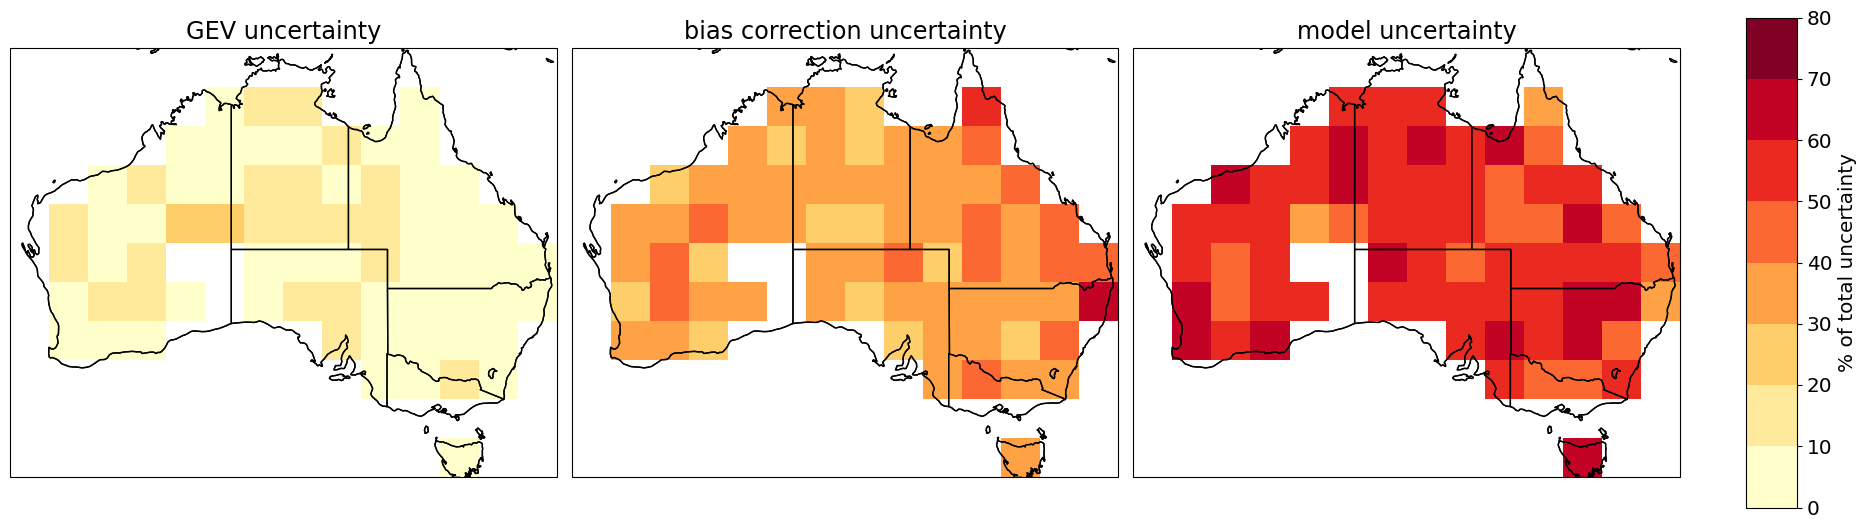

In [22]:
fig = plt.figure(figsize=[17, 7])
cbar_levels = np.arange(0, 81, 10)
cmap = 'YlOrRd'

ax1 = fig.add_subplot(131, projection=ccrs.PlateCarree())
im1 = ds.sel({'lev': return_period})['G'].plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    levels=cbar_levels,
    cmap=cmap,
)
ax1.set_title('GEV uncertainty')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)

ax2 = fig.add_subplot(132, projection=ccrs.PlateCarree())
im2 = ds.sel({'lev': return_period})['B'].plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    levels=cbar_levels,
    cmap=cmap,
)
ax2.set_title('bias correction uncertainty')
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)

ax3 = fig.add_subplot(133, projection=ccrs.PlateCarree())
im3 = ds.sel({'lev': return_period})['M'].plot(
    ax=ax3,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    levels=cbar_levels,
    cmap=cmap,
)
ax3.set_title('model uncertainty')
ax3.coastlines()
ax3.add_feature(cartopy.feature.STATES)

cbar_ax = fig.add_axes([1.03, 0.15, 0.03, 0.7]) # left, bottom, width, height
fig.colorbar(im1, cax=cbar_ax, label='% of total uncertainty')

plt.tight_layout()
plt.show()

In [23]:
ratio = ds.sel({'lev': return_period})['T'] / ds.sel({'lev': return_period})['O']

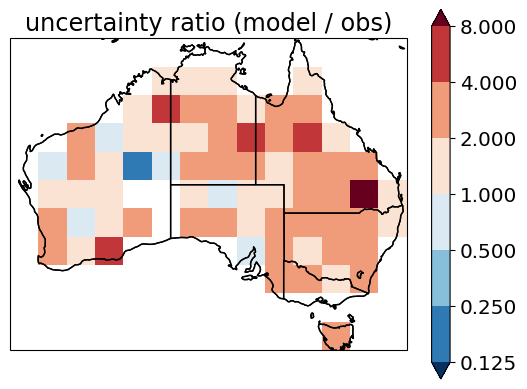

In [24]:
fig = plt.figure()#figsize=[5, 5])

ax1 = fig.add_subplot(111, projection=ccrs.PlateCarree())
im1 = ratio.plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    levels=[1/8, 1/4, 1/2, 1, 2, 4, 8],
    extend='both',
    cmap='RdBu_r'
)
ax1.set_title('uncertainty ratio (model / obs)')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)

plt.show()

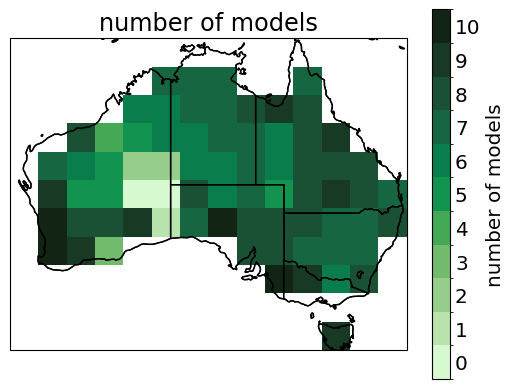

In [25]:
fig = plt.figure()#figsize=[5, 5])

ax1 = fig.add_subplot(111, projection=ccrs.PlateCarree())
im1 = ds['nmodels'].plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
#    cbar_kwargs={'label': ' '},
    levels=np.arange(-0.5, 10.6, 1.0),
#    extend='min',
    cmap=cmocean.cm.algae
)
ax1.set_title('number of models')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)

cbar = fig.colorbar(im1, ticks=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], label='number of models')
cbar.ax.tick_params(size=0)

plt.show()